In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

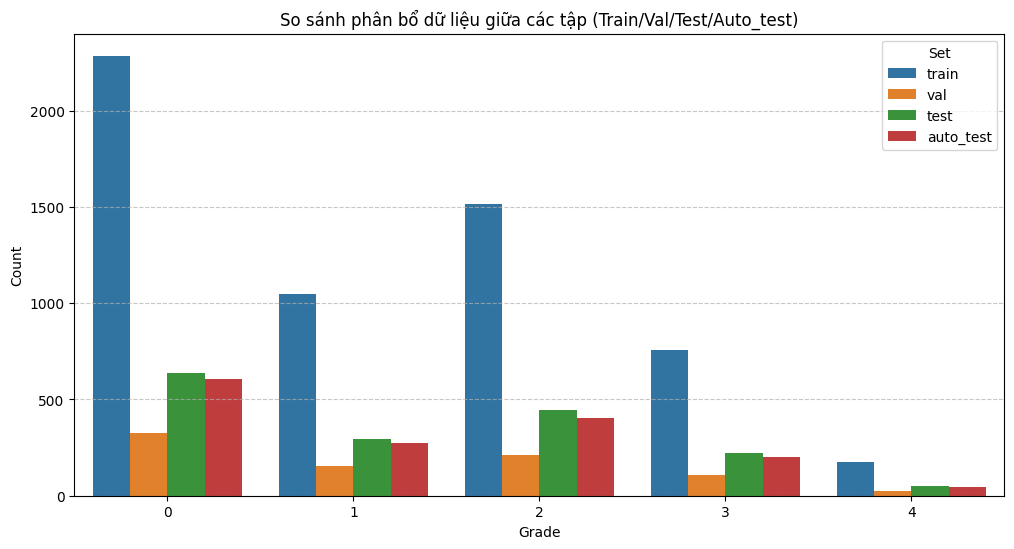

Bảng thống kê số lượng chi tiết:
Set    auto_test  test  train  val
Grade                             
0            604   639   2286  328
1            275   296   1046  153
2            403   447   1516  212
3            200   223    757  106
4             44    51    173   27


In [26]:
DATA_DIR = "../data/kneeKL224"
sets = ['train', 'val', 'test', 'auto_test']
all_stats = []

for s in sets:
    set_path = os.path.join(DATA_DIR, s)
    if os.path.exists(set_path):
        # Lấy danh sách các lớp (0, 1, 2, 3, 4)
        classes = sorted([d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))])
        for cls in classes:
            count = len(os.listdir(os.path.join(set_path, cls)))
            all_stats.append({"Set": s, "Grade": cls, "Count": count})

# Tạo DataFrame tổng
df_all = pd.DataFrame(all_stats)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
sns.barplot(data=df_all, x="Grade", y="Count", hue="Set")
plt.title("So sánh phân bổ dữ liệu giữa các tập (Train/Val/Test/Auto_test)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Hiển thị bảng số liệu chi tiết
df_pivot = df_all.pivot(index='Grade', columns='Set', values='Count').fillna(0).astype(int)
print("Bảng thống kê số lượng chi tiết:")
print(df_pivot)

# CLass info
1. Phân bố lớp 0 và 2 quá nhiều áp đảo 1 và 3 4.
2. tập Val lớp 4 quá ít không đánh giá tốt được.

In [27]:

# Lấy thử 1 ảnh ngẫu nhiên
sample_cls = df_stats['Grade'].iloc[0]
sample_img_name = os.listdir(os.path.join(DATA_DIR, 'train', sample_cls))[0]
sample_path = os.path.join(DATA_DIR, 'train', sample_cls, sample_img_name)

img = cv2.imread(sample_path)
print(f"Kích thước ảnh thực tế: {img.shape}") # (H, W, C)

Kích thước ảnh thực tế: (224, 224, 3)


# Image INFO
1. resize chuẩn với 224x224 và 3 kênh màu (RGB và BGR). Good for models.
2. Không cần convert lại khi train

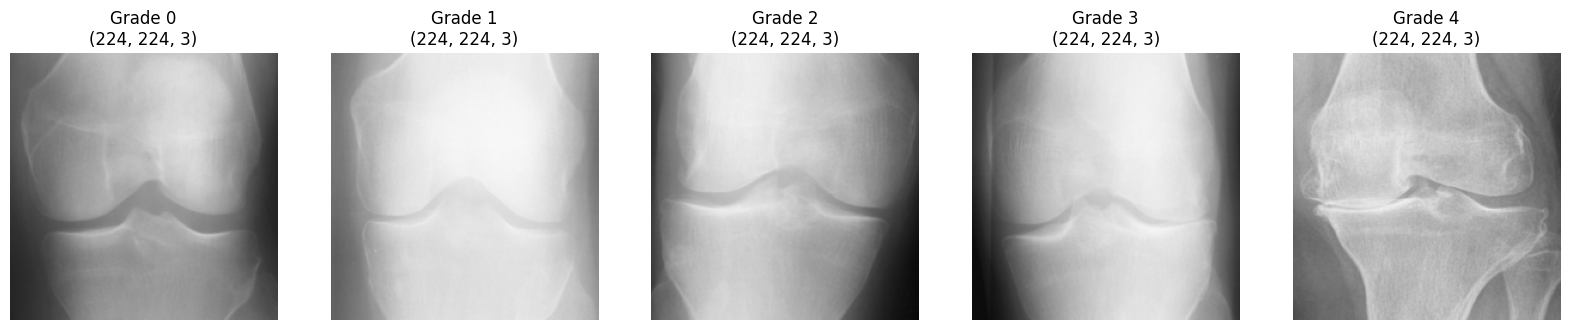

In [28]:
plt.figure(figsize=(20, 4))
for i, cls in enumerate(df_stats['Grade']):
    img_name = os.listdir(os.path.join(DATA_DIR, 'train', cls))[0]
    img_path = os.path.join(DATA_DIR, 'train', cls, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(f"Grade {cls}\n{img.shape}")
    plt.axis('off')
plt.show()

# What to do next?
1. Check grade 4
2. Agumentation

## Check grade 4

Tổng cộng có 173 ảnh Grade 4.


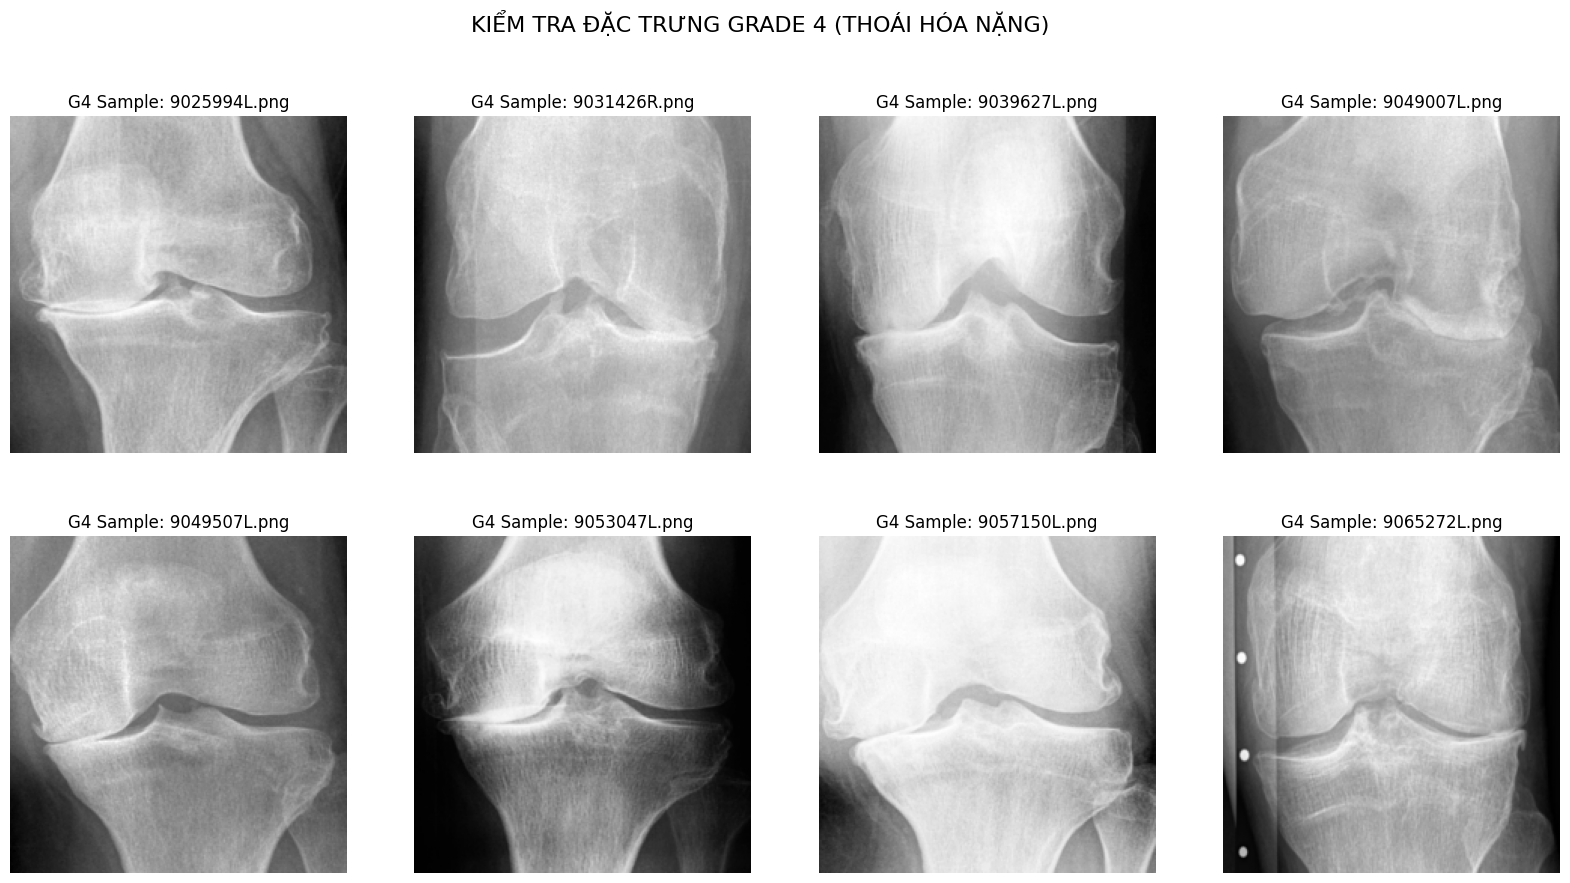

In [29]:


# Đường dẫn tới folder Grade 4 của tập train
g4_dir = os.path.join(DATA_DIR, 'train', '4')
g4_files = [f for f in os.listdir(g4_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"Tổng cộng có {len(g4_files)} ảnh Grade 4.")

# Hiển thị 8 ảnh mẫu để soi
plt.figure(figsize=(20, 10))
for i in range(min(8, len(g4_files))):
    img_path = os.path.join(g4_dir, g4_files[i])
    img = Image.open(img_path)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"G4 Sample: {g4_files[i]}")
    plt.axis('off')

plt.suptitle("KIỂM TRA ĐẶC TRƯNG GRADE 4 (THOÁI HÓA NẶNG)", fontsize=16)
plt.show()

## Agumentation

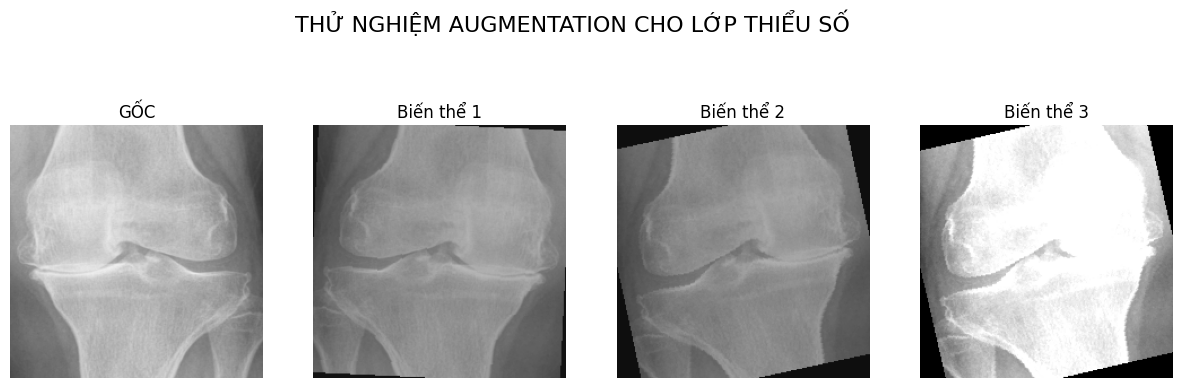

In [30]:
from torchvision import transforms

# Định nghĩa bộ transforms
test_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),     # Ép buộc lật để xem thử
    transforms.RandomRotation(degrees=15),      # Xoay nhẹ
    transforms.ColorJitter(brightness=0.3, contrast=0.3), # Chỉnh sáng tối mạnh hơn tí để test
    # Lưu ý: Ở đây chưa dùng ToTensor để dễ hiển thị ảnh bằng PIL
])

# Lấy 1 ảnh bất kỳ làm vật thí nghiệm
sample_img = Image.open(os.path.join(g4_dir, g4_files[0])).convert("RGB")

plt.figure(figsize=(15, 5))

# Ảnh gốc bên trái
plt.subplot(1, 4, 1)
plt.imshow(sample_img)
plt.title("GỐC")
plt.axis('off')

# 3 phiên bản biến dị bên phải
for i in range(3):
    aug_img = test_transform(sample_img)
    plt.subplot(1, 4, i + 2)
    plt.imshow(aug_img)
    plt.title(f"Biến thể {i+1}")
    plt.axis('off')

plt.suptitle("THỬ NGHIỆM AUGMENTATION CHO LỚP THIỂU SỐ", fontsize=16)
plt.show()

**INFO**


1. **Phân tích ảnh Grade 4 (Hình 1)**
- Mày có thể thấy rất rõ đặc trưng của Grade 4 (theo thang Kellgren-Lawrence):

    - Khe khớp biến mất hoàn toàn: Các đầu xương đùi và xương chày gần như chạm sát vào nhau (Joint Space Obliteration).

    - Gai xương (Osteophytes): Xuất hiện rất nhiều và to ở rìa khớp.

    - Xơ hóa xương dưới sụn: Các vùng xương trắng đậm hơn bình thường do ma sát.

2. **Nhận xét về Augmentation (Hình 2)**
- Nhìn vào các biến thể, tao thấy có một vấn đề nhỏ cần fix ở Biến thể 3:

    - Lỗi cháy sáng: Biến thể 3 bị đẩy contrast hoặc brightness lên quá cao làm vùng xương trắng xóa, mất hết chi tiết khe khớp. Nếu model học những ảnh này, nó sẽ bị nhiễu.

3. Lời khuyên: Trong code torchvision, giảm thông số ColorJitter xuống một chút:

- Thay vì brightness=0.3, contrast=0.3, hãy thử brightness=0.15, contrast=0.15.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load model ResNet18 đã học từ ImageNet
model = models.resnet18(pretrained=True)

# Thay đổi lớp cuối cùng (Fully Connected) để khớp với 5 lớp của mày (Grade 0-4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) 

# Đưa model lên GPU nếu có, không thì dùng CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Model đã sẵn sàng trên thiết bị: {device}")

In [ ]:
from torch.utils.data import DataLoader

# Khởi tạo Dataset
train_dataset = KneeDataset(DATA_DIR, split='train', transform=get_transforms('train'))
val_dataset = KneeDataset(DATA_DIR, split='val', transform=get_transforms('val'))

# Khởi tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam thường hội tụ nhanh hơn SGD

In [ ]:
epochs = 2 # Chạy thử 2 vòng cho biết

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Reset gradient
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass & Optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")